## Advanced Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
df = pd.read_csv('../data/encoded_data.csv')

- We will build a Logistic Regression Model.
    - a statistical model to predict the churn customer

In [5]:
X = df.drop(columns=['CustomerID', 'Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Build and Train the Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 5. Test the Model
predictions = model.predict(X_test)
print("--- MODEL ACCURACY REPORT ---")
print(classification_report(y_test, predictions))

--- MODEL ACCURACY REPORT ---
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        84
           1       0.82      0.88      0.85        16

    accuracy                           0.95       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.95      0.95      0.95       100



C:\Users\Mohith M\AppData\Local\Temp\ipykernel_13024\3108951144.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm_r')


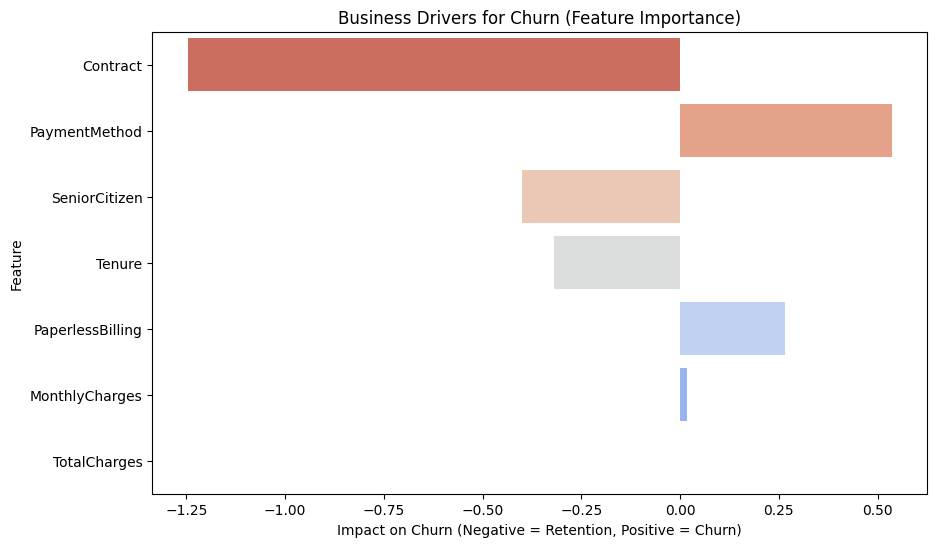

In [6]:
#  Extract Feature Importance (Which factors drive the model the most?)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_[0]
})
# Sort by absolute value to see the biggest impact (positive or negative)
feature_importance['Abs_Importance'] = feature_importance['Importance'].abs()
feature_importance = feature_importance.sort_values(by='Abs_Importance', ascending=False)

#  Visualize Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='coolwarm_r')
plt.title('Business Drivers for Churn (Feature Importance)')
plt.xlabel('Impact on Churn (Negative = Retention, Positive = Churn)')
plt.show()